# Bag of words

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device:", torch.cuda.current_device())
else:
    print("Running on CPU")

CUDA available: True
GPU name: NVIDIA GeForce RTX 4080
Current device: 0


In [2]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
print(df.head())
print(df.columns)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='str')


In [3]:
df = df.dropna()              # clean missing values
df = df.sample(1000, random_state=42)  # take 1k random rows

print(df.shape)
print(df.head())

(1000, 2)
                                                  review sentiment
33553  I really liked this Summerslam due to the look...  positive
9427   Not many television shows appeal to quite as m...  positive
199    The film quickly gets to a major chase scene w...  negative
12447  Jane Austen would definitely approve of this o...  positive
39489  Expectations were somewhat high for me when I ...  negative


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20000
)

X = vectorizer.fit_transform(df["review"])
y = df["sentiment"]

In [6]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 89067 stored elements and shape (1000, 17589)>
  Coords	Values
  (0, 12679)	1
  (0, 9261)	1
  (0, 15296)	2
  (0, 9418)	2
  (0, 972)	1
  (0, 3897)	1
  (0, 8688)	2
  (0, 11168)	1
  (0, 8283)	2
  (0, 12689)	1
  (0, 880)	1
  (0, 1620)	1
  (0, 17469)	1
  (0, 4424)	1
  (0, 9211)	2
  (0, 9527)	3
  (0, 9638)	2
  (0, 5493)	3
  (0, 17520)	2
  (0, 15897)	1
  (0, 10975)	1
  (0, 7692)	1
  (0, 5844)	1
  (0, 9675)	2
  (0, 16973)	5
  :	:
  (999, 12241)	1
  (999, 4980)	1
  (999, 3560)	1
  (999, 8388)	1
  (999, 9181)	1
  (999, 3710)	1
  (999, 12335)	1
  (999, 5706)	1
  (999, 10507)	1
  (999, 8694)	1
  (999, 5037)	1
  (999, 4221)	1
  (999, 10827)	1
  (999, 8409)	1
  (999, 13284)	1
  (999, 6436)	1
  (999, 9733)	1
  (999, 15683)	1
  (999, 967)	1
  (999, 1869)	1
  (999, 6623)	1
  (999, 4354)	1
  (999, 7641)	1
  (999, 11895)	1
  (999, 5482)	1


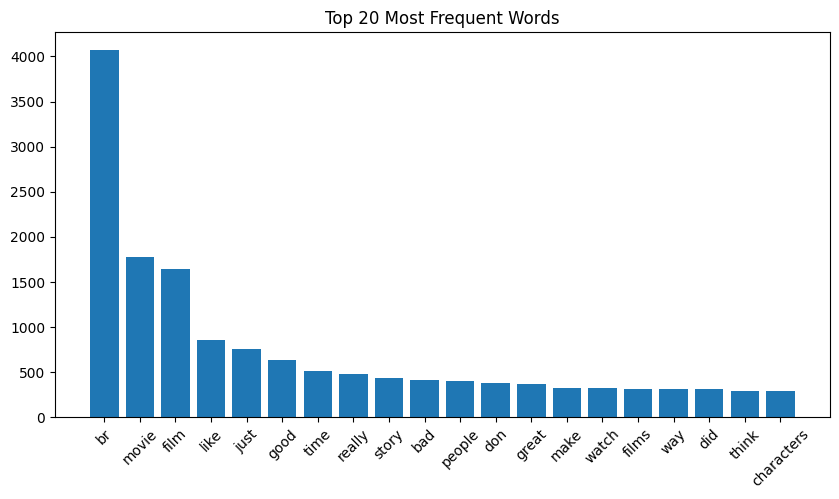

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Get word counts
word_counts = np.asarray(X.sum(axis=0)).flatten()
words = vectorizer.get_feature_names_out()

# Sort by frequency
top_idx = word_counts.argsort()[::-1][:20]

top_words = words[top_idx]
top_counts = word_counts[top_idx]

# Plot
plt.figure(figsize=(10,5))
plt.bar(top_words, top_counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

# Model training

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# convert y to numpy (important for safety)
y_arr = y.to_numpy()

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_arr,
    test_size=0.2,
    random_state=42
)

# model
model = LogisticRegression(max_iter=1000)

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.795
              precision    recall  f1-score   support

    negative       0.83      0.81      0.82       114
    positive       0.75      0.78      0.77        86

    accuracy                           0.80       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.80      0.80      0.80       200



# Visualization of the model

In [9]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

In [10]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X.toarray())

In [11]:
model_2d = LogisticRegression()
model_2d.fit(X_2d, y.to_numpy())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
x_min, x_max = X_2d[:,0].min() - 1, X_2d[:,0].max() + 1
y_min, y_max = X_2d[:,1].min() - 1, X_2d[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_2d.predict(grid)
Z = Z.reshape(xx.shape)

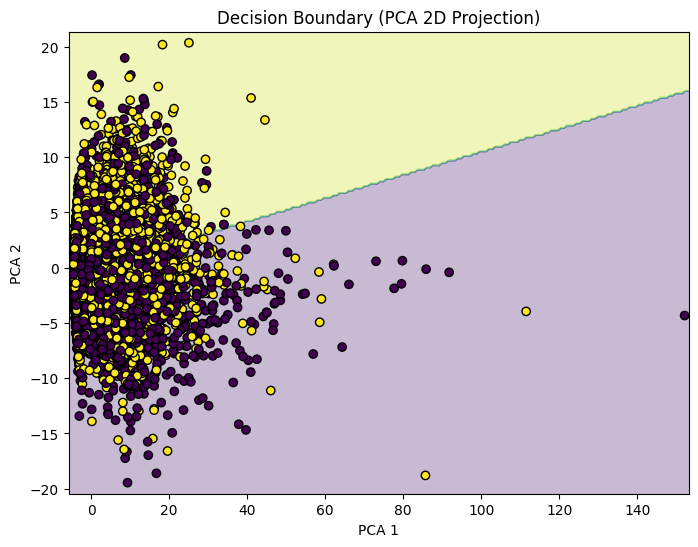

In [19]:
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, edgecolor='k')

plt.title("Decision Boundary (PCA 2D Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## Word weighting 

In [9]:
import numpy as np
import pandas as pd

words = vectorizer.get_feature_names_out()

weights = model.coef_[0]   # for binary classification

In [10]:
df_weights = pd.DataFrame({
    "word": words,
    "weight": weights
})

df_weights.head()

,word,weight
0,00,-0.037541
1,000,-0.018487
2,01,0.034742
3,02,0.007541
4,04,0.000000


In [11]:
top_positive = df_weights.sort_values(by="weight", ascending=False).head(20)
top_positive

,word,weight
6933,great,1.055511
1620,best,0.822620
698,amazing,0.717310
5548,excellent,0.653142
5322,enjoyed,0.630713
4973,dvd,0.573463
15941,today,0.560450
2066,brilliant,0.546420
10673,new,0.539393
15319,superb,0.532303


## Inference

In [19]:
new_texts = [
    "This movie was not unamazing, I did not love it!",
    "Worst experience ever, very boring and slow."
]

# IMPORTANT: transform (NOT fit_transform)
X_new = vectorizer.transform(new_texts)

predictions = model.predict(X_new)

print(predictions)

['positive' 'negative']
